# Phi_deg Modeling Notebook

This notebook trains a dedicated regression workflow for the soil friction-angle target `Phi_deg`.

Workflow:
1. Load the dense target-specific CSV prepared during harmonization.
2. Verify that the remaining deterministic soil relationships are understood before modeling.
3. Build `Phi_deg`-specific engineered features focused on plasticity, density, and gradation.
4. Compare 6 regression models using 5-fold shuffled cross-validation.
5. Diagnose the best model with parity, residual, and permutation-importance plots.
6. Export the model comparison table, OOF predictions, feature importance, and fitted best model.

In [1]:
# Standard library imports
from pathlib import Path
import warnings

# Data manipulation and notebook display helpers
import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    from sklearn.ensemble import AdaBoostRegressor
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='talk')

RANDOM_STATE = 42
TARGET_COLUMN = 'Phi_deg'
DATA_FILE = 'geotechnical_phi_training_ready.csv'
ARTIFACT_STEM = 'phi'

def resolve_project_root() -> Path:
    candidate = Path.cwd().resolve()
    if (candidate / 'outputs').exists():
        return candidate
    if (candidate.parent / 'outputs').exists():
        return candidate.parent
    raise FileNotFoundError('Could not locate the project root containing the outputs directory.')

PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATA_PATH = OUTPUT_DIR / DATA_FILE

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {DATA_PATH}')

Project root: /Users/apple/Downloads/Soil-Properties-Prediction
Dataset path: /Users/apple/Downloads/Soil-Properties-Prediction/outputs/geotechnical_phi_training_ready.csv


In [2]:
# Load the dense target-specific dataset created by the harmonization notebook.
data_df = pd.read_csv(DATA_PATH)

# Confirm the CSV is complete before any modeling work starts.
quality_summary = pd.DataFrame({
    'dtype': data_df.dtypes.astype(str),
    'missing_values': data_df.isna().sum(),
    'unique_values': data_df.nunique(),
}).sort_index()

print(f'Rows: {data_df.shape[0]}')
print(f'Columns: {data_df.shape[1]}')
display(data_df.head())
display(quality_summary)
display(data_df.describe().T.round(3))

Rows: 228
Columns: 11


,LL,PL,PI,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Grain_CoarsePassing_pct,Fines_Content_pct,Sand_Fraction_pct,Gravel_Fraction_pct,Phi_deg
0,47.0,35.5,11.5,18.8352,0.47,0.85,99.2,36.5,62.7,0.8,10.0
1,48.5,36.4,12.1,18.9333,0.50,0.91,98.5,35.2,63.3,1.5,12.0
2,44.8,30.8,14.0,18.4428,0.39,0.95,98.6,45.3,53.3,1.4,15.0
3,48.0,37.0,11.0,19.2276,0.49,0.85,97.6,38.5,59.1,2.4,16.0
4,46.5,36.7,9.8,19.3257,0.41,0.72,96.8,36.3,60.5,3.2,16.0


,dtype,missing_values,unique_values
Cv_50kPa,float64,0,96
Fines_Content_pct,float64,0,133
Grain_CoarsePassing_pct,float64,0,51
Gravel_Fraction_pct,float64,0,51
LL,float64,0,144
Mv_50kPa,float64,0,56
PI,float64,0,107
PL,float64,0,153
Phi_deg,float64,0,15
Sand_Fraction_pct,float64,0,148


,count,mean,std,min,25%,50%,75%,max
LL,228.0,37.647,14.441,14.900,28.350,38.100,44.800,95.00
PL,228.0,21.972,8.360,3.700,16.800,21.350,26.900,40.60
PI,228.0,15.675,9.009,4.200,11.200,13.150,18.000,56.80
Sat_Unit_Wt_kN_m3,228.0,18.253,1.382,13.538,17.952,18.345,18.933,20.50
Mv_50kPa,228.0,0.405,0.164,0.130,0.288,0.390,0.490,0.94
Cv_50kPa,228.0,0.943,0.432,0.290,0.650,0.840,1.120,2.41
Grain_CoarsePassing_pct,228.0,98.090,2.543,85.000,97.600,98.600,99.925,100.00
Fines_Content_pct,228.0,38.514,12.594,12.000,31.400,36.250,44.000,87.80
Sand_Fraction_pct,228.0,59.575,12.115,10.600,54.000,62.050,67.025,83.00
Gravel_Fraction_pct,228.0,1.910,2.543,0.000,0.075,1.400,2.400,15.00


In [3]:
# The cleaned CSV is dense, but some columns remain exact algebraic rearrangements of others.
# We check those relationships first and then rebuild a smaller, less redundant feature space.
redundancy_checks = pd.Series({
    'max|PI - (LL - PL)|': (data_df['PI'] - (data_df['LL'] - data_df['PL'])).abs().max(),
    'max|Grain_CoarsePassing_pct - (100 - Gravel_Fraction_pct)|': (
        data_df['Grain_CoarsePassing_pct'] - (100.0 - data_df['Gravel_Fraction_pct'])
    ).abs().max(),
    'max|Fines + Sand + Gravel - 100|': (
        data_df['Fines_Content_pct'] + data_df['Sand_Fraction_pct'] + data_df['Gravel_Fraction_pct'] - 100.0
    ).abs().max(),
})
display(redundancy_checks.to_frame('check_value'))

def build_phi_features(frame: pd.DataFrame):
    feature_frame = frame.copy()

    # Reconstruct plasticity from LL and PL instead of passing the exact duplicate PI column.
    feature_frame['PI_calc'] = feature_frame['LL'] - feature_frame['PL']
    feature_frame['Plasticity_to_LL'] = feature_frame['PI_calc'] / feature_frame['LL'].clip(lower=1e-6)

    # Rebuild coarse-grain descriptors from the dense composition columns.
    feature_frame['Coarse_Fraction_pct'] = 100.0 - feature_frame['Fines_Content_pct']
    feature_frame['Sand_to_Fines_Ratio'] = feature_frame['Sand_Fraction_pct'] / (feature_frame['Fines_Content_pct'] + 1.0)
    feature_frame['Gravel_to_Sand_Ratio'] = feature_frame['Gravel_Fraction_pct'] / (feature_frame['Sand_Fraction_pct'] + 1.0)

    # Blend consolidation and density terms because friction angle is sensitive to density and granular makeup.
    feature_frame['Mv_to_Cv_Ratio'] = feature_frame['Mv_50kPa'] / feature_frame['Cv_50kPa'].clip(lower=1e-6)
    feature_frame['Density_x_Sand'] = feature_frame['Sat_Unit_Wt_kN_m3'] * feature_frame['Sand_Fraction_pct']

    model_columns = [
        'LL',
        'PL',
        'Sat_Unit_Wt_kN_m3',
        'Mv_50kPa',
        'Cv_50kPa',
        'Fines_Content_pct',
        'Sand_Fraction_pct',
        'PI_calc',
        'Plasticity_to_LL',
        'Coarse_Fraction_pct',
        'Sand_to_Fines_Ratio',
        'Gravel_to_Sand_Ratio',
        'Mv_to_Cv_Ratio',
        'Density_x_Sand',
    ]
    X = feature_frame[model_columns].copy()
    y = feature_frame[TARGET_COLUMN].copy()
    return X, y

X, y = build_phi_features(data_df)
assert not X.isna().any().any(), 'Feature matrix should not contain missing values.'
assert np.isfinite(X.to_numpy()).all(), 'Feature matrix should be finite.'

print(f'Modeling matrix shape: {X.shape}')
display(X.head())

,check_value
max|PI - (LL - PL)|,7.105427e-15
max|Grain_CoarsePassing_pct - (100 - Gravel_Fraction_pct)|,0.000000e+00
max|Fines + Sand + Gravel - 100|,1.421085e-14


Modeling matrix shape: (228, 14)


,LL,PL,Sat_Unit_Wt_kN_m3,Mv_50kPa,Cv_50kPa,Fines_Content_pct,Sand_Fraction_pct,PI_calc,Plasticity_to_LL,Coarse_Fraction_pct,Sand_to_Fines_Ratio,Gravel_to_Sand_Ratio,Mv_to_Cv_Ratio,Density_x_Sand
0,47.0,35.5,18.8352,0.47,0.85,36.5,62.7,11.5,0.244681,63.5,1.672000,0.012559,0.552941,1180.96704
1,48.5,36.4,18.9333,0.50,0.91,35.2,63.3,12.1,0.249485,64.8,1.748619,0.023328,0.549451,1198.47789
2,44.8,30.8,18.4428,0.39,0.95,45.3,53.3,14.0,0.312500,54.7,1.151188,0.025783,0.410526,983.00124
3,48.0,37.0,19.2276,0.49,0.85,38.5,59.1,11.0,0.229167,61.5,1.496203,0.039933,0.576471,1136.35116
4,46.5,36.7,19.3257,0.41,0.72,36.3,60.5,9.8,0.210753,63.7,1.621984,0.052033,0.569444,1169.20485


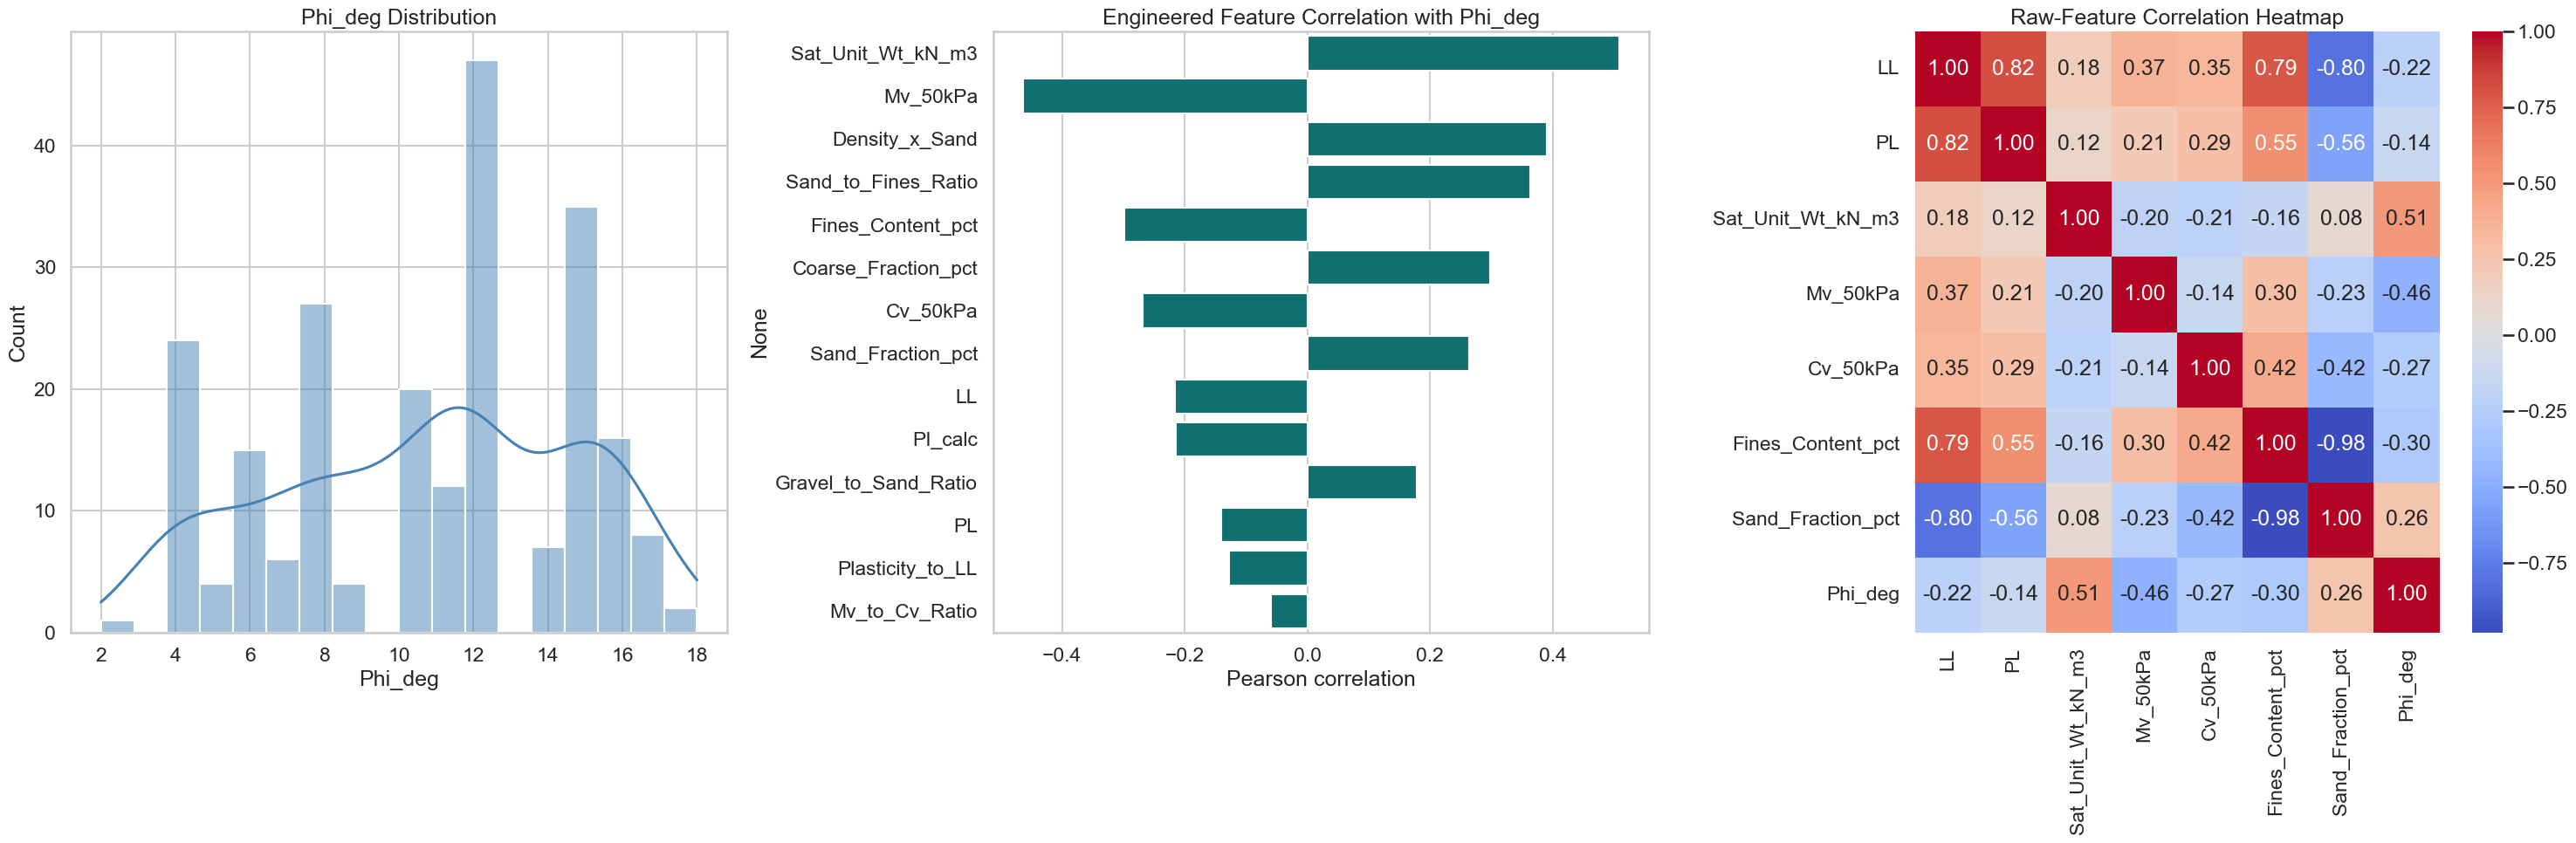

In [8]:
# Build a compact EDA panel so the target distribution and the strongest raw correlations are visible.
corr_with_target = (
    X.assign(Phi_deg=y)
    .corr(numeric_only=True)['Phi_deg']
    .drop('Phi_deg')
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

sns.histplot(y, kde=True, bins=18, ax=axes[0], color='steelblue')
axes[0].set_title('Phi_deg Distribution')
axes[0].set_xlabel('Phi_deg')

sns.barplot(x=corr_with_target.values, y=corr_with_target.index, ax=axes[1], color='teal')
axes[1].set_title('Engineered Feature Correlation with Phi_deg')
axes[1].set_xlabel('Pearson correlation')

heatmap_columns = [
    'LL',
    'PL',
    'Sat_Unit_Wt_kN_m3',
    'Mv_50kPa',
    'Cv_50kPa',
    'Fines_Content_pct',
    'Sand_Fraction_pct',
    TARGET_COLUMN,
]
sns.heatmap(data_df[heatmap_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Raw-Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## Model Comparison

The comparison uses shuffled 5-fold cross-validation. Two scaled linear baselines are included to show the penalty for forcing a mostly linear relationship, while the tree-based ensembles capture non-linear soil behaviour and interaction effects more naturally.

In [5]:
# Use an explicit RMSE helper to stay compatible with sklearn builds that do not expose squared=False.
def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metric_frame(y_true, y_pred):
    return {
        'OOF_RMSE': root_mean_squared_error(y_true, y_pred),
        'OOF_MAE': float(mean_absolute_error(y_true, y_pred)),
        'OOF_R2': float(r2_score(y_true, y_pred)),
    }

def build_model_candidates():
    models = {
        'Linear Regression': Pipeline([
            ('scale', StandardScaler()),
            ('model', LinearRegression()),
        ]),
        'Ridge Regression': Pipeline([
            ('scale', StandardScaler()),
            ('model', Ridge(alpha=1.0)),
        ]),
        'Random Forest': RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        'Extra Trees': ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            learning_rate=0.05,
            n_estimators=300,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    else:
        models['AdaBoost'] = AdaBoostRegressor(
            n_estimators=300,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        )
    return models

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': 'r2',
}

evaluation_rows = []
oof_predictions = {}
model_candidates = build_model_candidates()

for model_name, model in model_candidates.items():
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    preds = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    oof_predictions[model_name] = preds

    row = {
        'Model': model_name,
        'CV_RMSE_Mean': -cv_scores['test_rmse'].mean(),
        'CV_RMSE_STD': cv_scores['test_rmse'].std(),
        'CV_MAE_Mean': -cv_scores['test_mae'].mean(),
        'CV_R2_Mean': cv_scores['test_r2'].mean(),
    }
    row.update(metric_frame(y, preds))
    evaluation_rows.append(row)

results_df = pd.DataFrame(evaluation_rows).sort_values('OOF_RMSE').reset_index(drop=True)
best_model_name = results_df.loc[0, 'Model']
best_model = clone(model_candidates[best_model_name])

display(results_df.round(4))
print(f'Best model based on OOF RMSE: {best_model_name}')

,Model,CV_RMSE_Mean,CV_RMSE_STD,CV_MAE_Mean,CV_R2_Mean,OOF_RMSE,OOF_MAE,OOF_R2
0,Extra Trees,1.3931,0.1697,0.9565,0.8708,1.4034,0.9568,0.8750
1,XGBoost,1.6499,0.1674,1.1221,0.8203,1.6589,1.1222,0.8253
2,Gradient Boosting,1.7837,0.1644,1.2167,0.7912,1.7920,1.2165,0.7962
3,Random Forest,1.8524,0.3312,1.2928,0.7693,1.8828,1.2930,0.7750
4,Linear Regression,2.5417,0.2897,2.0060,0.5693,2.5566,2.0049,0.5851
5,Ridge Regression,2.8767,0.2731,2.3290,0.4492,2.8876,2.3277,0.4707


Best model based on OOF RMSE: Extra Trees


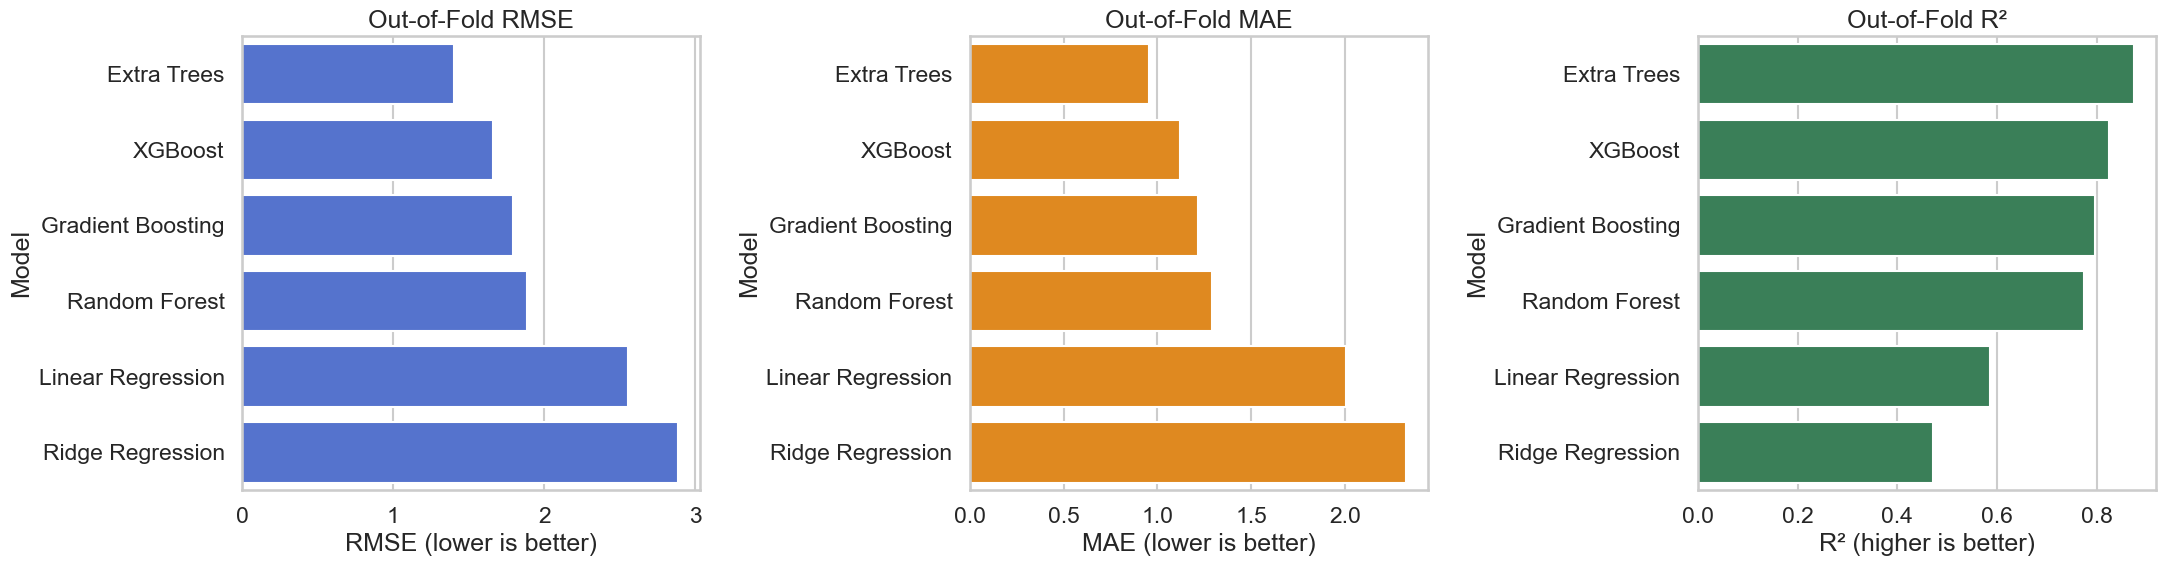

In [6]:
# Plot the model comparison so the ranking is easy to interpret at a glance.
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=results_df, x='OOF_RMSE', y='Model', ax=axes[0], color='royalblue')
axes[0].set_title('Out-of-Fold RMSE')
axes[0].set_xlabel('RMSE (lower is better)')

sns.barplot(data=results_df, x='OOF_MAE', y='Model', ax=axes[1], color='darkorange')
axes[1].set_title('Out-of-Fold MAE')
axes[1].set_xlabel('MAE (lower is better)')

sns.barplot(data=results_df, x='OOF_R2', y='Model', ax=axes[2], color='seagreen')
axes[2].set_title('Out-of-Fold R²')
axes[2].set_xlabel('R² (higher is better)')

plt.tight_layout()
plt.show()

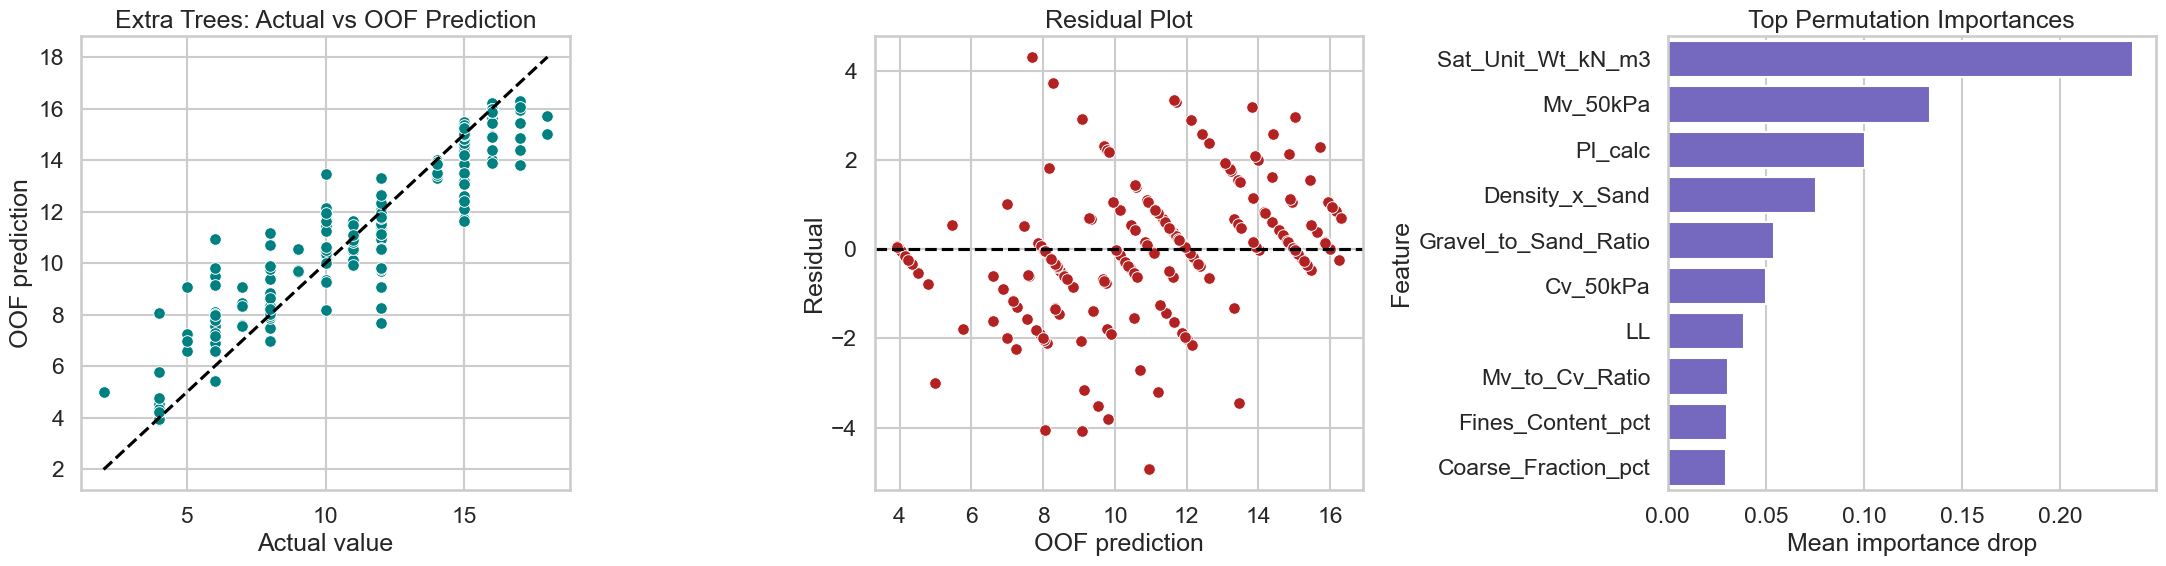

,value
Best model,Extra Trees
Comparison CSV,phi_model_comparison.csv
OOF predictions CSV,phi_oof_predictions.csv
Feature importance CSV,phi_feature_importance.csv
Best model artifact,phi_best_model.joblib


,Feature,Importance,Importance_STD
0,Sat_Unit_Wt_kN_m3,0.2370,0.0204
1,Mv_50kPa,0.1335,0.0150
2,PI_calc,0.1003,0.0100
3,Density_x_Sand,0.0758,0.0064
4,Gravel_to_Sand_Ratio,0.0541,0.0058
5,Cv_50kPa,0.0503,0.0038
6,LL,0.0387,0.0036
7,Mv_to_Cv_Ratio,0.0306,0.0029
8,Fines_Content_pct,0.0303,0.0026
9,Coarse_Fraction_pct,0.0299,0.0024


In [7]:
# Fit the winning model on the full dataset, then inspect prediction quality and feature importance.
best_model.fit(X, y)
best_oof = oof_predictions[best_model_name]
residuals = y - best_oof

importance = permutation_importance(
    best_model,
    X,
    y,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance.importances_mean,
        'Importance_STD': importance.importances_std,
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(x=y, y=best_oof, ax=axes[0], color='teal', s=70, edgecolor='white')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--', color='black')
axes[0].set_title(f'{best_model_name}: Actual vs OOF Prediction')
axes[0].set_xlabel('Actual value')
axes[0].set_ylabel('OOF prediction')

sns.scatterplot(x=best_oof, y=residuals, ax=axes[1], color='firebrick', s=70, edgecolor='white')
axes[1].axhline(0.0, linestyle='--', color='black')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('OOF prediction')
axes[1].set_ylabel('Residual')

sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', ax=axes[2], color='slateblue')
axes[2].set_title('Top Permutation Importances')
axes[2].set_xlabel('Mean importance drop')

plt.tight_layout()
plt.show()

comparison_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_model_comparison.csv'
oof_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_oof_predictions.csv'
model_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_best_model.joblib'
importance_path = OUTPUT_DIR / f'{ARTIFACT_STEM}_feature_importance.csv'

results_df.to_csv(comparison_path, index=False)
pd.DataFrame({
    'Actual': y,
    'OOF_Prediction': best_oof,
    'Residual': residuals,
}).to_csv(oof_path, index=False)
importance_df.to_csv(importance_path, index=False)
joblib.dump(best_model, model_path)

export_summary = pd.Series({
    'Best model': best_model_name,
    'Comparison CSV': comparison_path.name,
    'OOF predictions CSV': oof_path.name,
    'Feature importance CSV': importance_path.name,
    'Best model artifact': model_path.name,
})
display(export_summary.to_frame('value'))
display(importance_df.head(10).round(4))

## Takeaway

Use the exported comparison table to compare all models numerically and keep the saved best-model artifact for downstream prediction work. The importance chart in this notebook is descriptive rather than causal, but it is still useful for checking whether the model is leaning on sensible geotechnical drivers.